In [196]:
from sklearn.datasets import fetch_covtype
from dataloading import prepare_data
from utils import train_iteratively, uncertainty
import plots
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Load dataset

In [197]:
cov_type = fetch_covtype()
np.unique_counts(cov_type["target"]).counts

array([211840, 283301,  35754,   2747,   9493,  17367,  20510])

# Plot class imbalance  

In [198]:
def plot_downsampled_distribution(data):
    plt.subplot(2, 2, 1)
    plots.plot_class_distribution(cov_type["target"], "Original", show = False)

    plt.subplot(2, 2, 2)
    plots.plot_class_distribution(data['train']['y'], "Train", show = False)

    plt.subplot(2, 2, 3)
    plots.plot_class_distribution(data['pool']['y'], "Pool", show = False)

    plt.subplot(2, 2, 4)
    plots.plot_class_distribution(data['test']['y'], "Test", show = False)

    plt.suptitle("Class distributions")
    plt.tight_layout()
    plt.show()


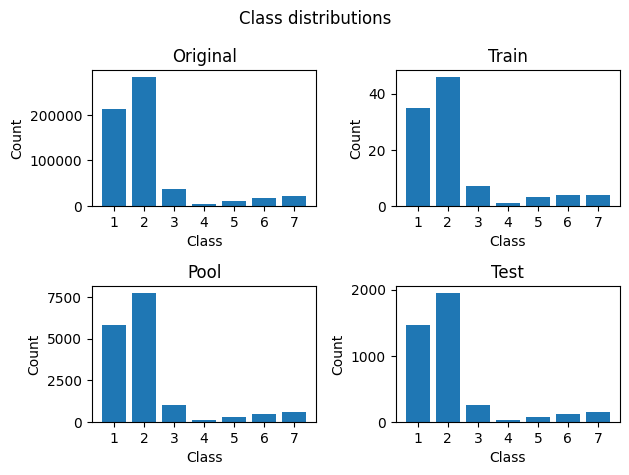

In [199]:
data,explained_var = prepare_data(
    cov_type,
    n_init=100,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=False
)
plot_downsampled_distribution(data)

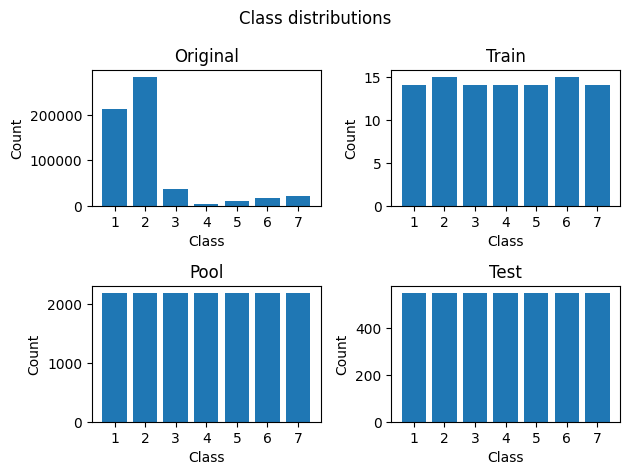

In [200]:
data,explained_var = prepare_data(
    cov_type,
    n_init=100,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=True
)

plot_downsampled_distribution(data)

# Train the model

In [201]:
class_names = sorted(set(cov_type['target']))
class_counts = []
for i in range(1,8):
    class_counts.append(sum(data['pool']['y']==i))

class_legends = [f"Class {class_names[i]} ({class_counts[i]})" for i in range(7)]

In [ ]:
def run_and_plot(class_legends):
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    y_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

    for i, method in enumerate(["random", "entropy", "least_confident", "margin"]):
        data, explained_var = prepare_data(
            cov_type,
            n_init=14,
            n_points=30000,   # optional (set None to use full dataset)
            seed=42,
            even_distribution=False
        )
        model = LogisticRegression(solver='lbfgs', max_iter=400)

        test_acc, test_acc_byclass = train_iteratively(
            data=data,
            model=model,
            measure=method,
            addn=1,
            iterations=100
        )

        ax = axes.flat[i]
        for clas in range(7): # plot class accuracies
            ax.plot(
                [x[0] for x in test_acc_byclass[clas]],
                [x[1] for x in test_acc_byclass[clas]],
                label=class_legends[clas],
                alpha=0.7
            )
        # Plot total accuracy
        ax.plot([x[0] for x in test_acc], [x[1] for x in test_acc], color="k", label="Total accuracy")
        
        ax.set_ylabel("Accuracy")
        ax.set_xlabel("Num point")
        ax.set_title(f"{method} sampling")
        ax.set_ylim(0, 1.0)
        ax.set_yticks(y_ticks)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
    fig.suptitle("Model training")
    fig.tight_layout()
    plt.show()


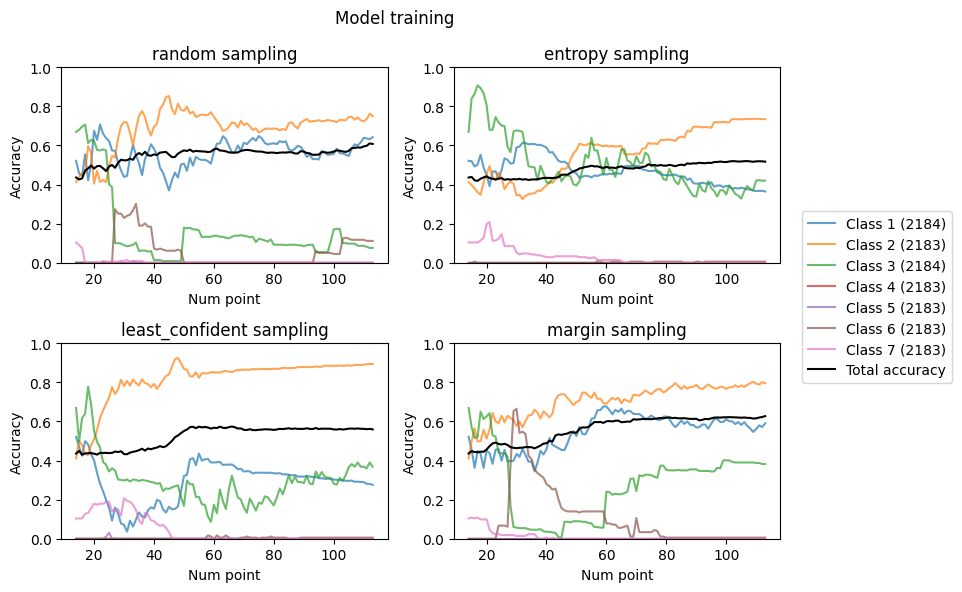

In [238]:
run_and_plot(class_legends)